<a href="https://colab.research.google.com/github/ritesh23r/Fitbit_Case_study/blob/main/Fitbit_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seb

In [7]:
df1 = pd.read_excel('dailyActivity_merged_cleaned.xlsx')
df2 = pd.read_excel('sleepDay_merged_cleaned.xlsx')

In [8]:
merged_df = pd.merge(df1,df2,
    left_on=['Id', 'ActivityDate'],
    right_on=['Id', 'SleepDay'],
    how='inner'
)
merged_df.drop('SleepDay', axis=1, inplace=True)
merged_df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.50,25,13,328,728,1985,1,327,346
1,1503960366,2016-04-13,10735,6.97,21,19,217,776,1797,2,384,407
2,1503960366,2016-04-15,9762,6.28,29,34,209,726,1745,1,412,442
3,1503960366,2016-04-16,12669,8.16,36,10,221,773,1863,2,340,367
4,1503960366,2016-04-17,9705,6.48,38,20,164,539,1728,1,700,712


In [9]:
merged_df.shape

(413, 12)

In [10]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    413 non-null    int64         
 1   ActivityDate          413 non-null    datetime64[ns]
 2   TotalSteps            413 non-null    int64         
 3   TotalDistance         413 non-null    float64       
 4   VeryActiveMinutes     413 non-null    int64         
 5   FairlyActiveMinutes   413 non-null    int64         
 6   LightlyActiveMinutes  413 non-null    int64         
 7   SedentaryMinutes      413 non-null    int64         
 8   Calories              413 non-null    int64         
 9   TotalSleepRecords     413 non-null    int64         
 10  TotalMinutesAsleep    413 non-null    int64         
 11  TotalTimeInBed        413 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(10)
memory usage: 38.8 KB


In [11]:
merged_df.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,4.130000e+02,413,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000
mean,5.000979e+09,2016-04-26 12:40:05.811137792,8541.140436,6.038620,25.188862,18.038741,216.854722,712.169492,2397.573850,1.118644,419.467312,458.639225
min,1.503960e+09,2016-04-12 00:00:00,17.000000,0.010000,0.000000,0.000000,2.000000,0.000000,257.000000,1.000000,58.000000,61.000000
25%,3.977334e+09,2016-04-19 00:00:00,5206.000000,3.600000,0.000000,0.000000,158.000000,631.000000,1850.000000,1.000000,361.000000,403.000000
50%,4.702922e+09,2016-04-27 00:00:00,8925.000000,6.290000,9.000000,11.000000,208.000000,717.000000,2220.000000,1.000000,433.000000,463.000000
75%,6.962181e+09,2016-05-04 00:00:00,11393.000000,8.030000,38.000000,27.000000,263.000000,783.000000,2926.000000,1.000000,490.000000,526.000000
max,8.792010e+09,2016-05-12 00:00:00,22770.000000,17.540000,210.000000,143.000000,518.000000,1265.000000,4900.000000,3.000000,796.000000,961.000000
std,2.060360e+09,NaN,4156.926990,3.051998,36.388187,22.403590,87.164687,165.957432,762.886326,0.345521,118.344679,127.101607


In [12]:
merged_df.isnull().sum()

,0
Id,0
ActivityDate,0
TotalSteps,0
TotalDistance,0
VeryActiveMinutes,0
FairlyActiveMinutes,0
LightlyActiveMinutes,0
SedentaryMinutes,0
Calories,0
TotalSleepRecords,0


In [13]:
merged_df.rename(columns={'ActivityDate': 'Date'}, inplace=True)

In [14]:
merged_df.duplicated().sum()

np.int64(3)

In [15]:
merged_df.drop_duplicates(inplace=True)

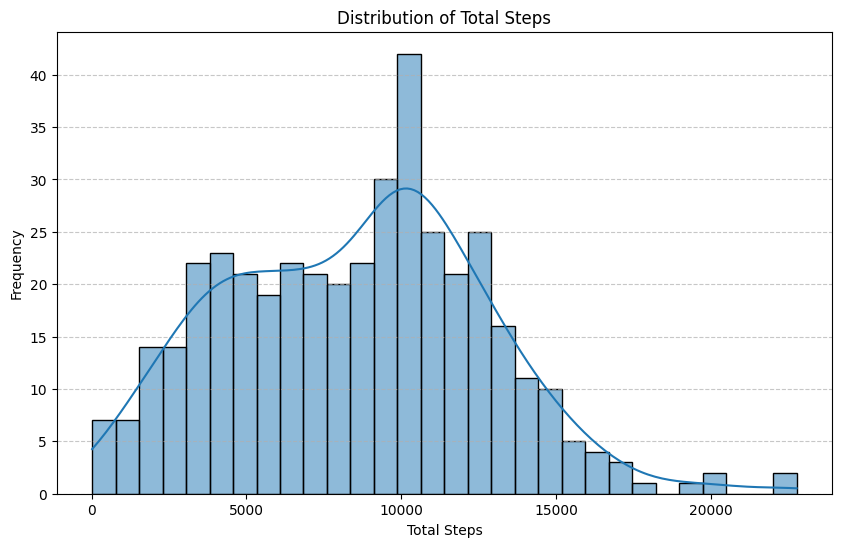

In [16]:
plt.figure(figsize=(10, 6))
seb.histplot(merged_df['TotalSteps'], bins=30, kde=True)
plt.title('Distribution of Total Steps')
plt.xlabel('Total Steps')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Axes: xlabel='Calories', ylabel='Count'>

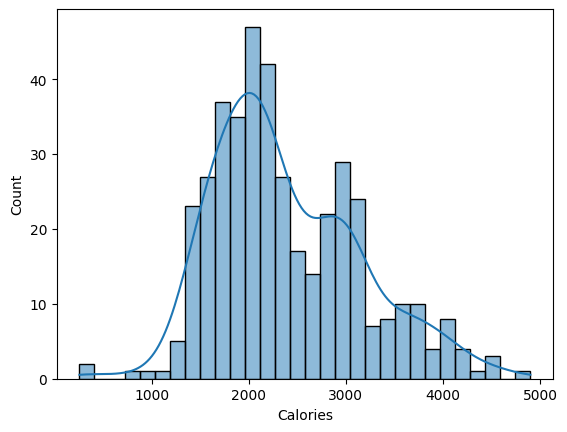

In [17]:
seb.histplot(merged_df['Calories'], bins=30, kde=True)

In [18]:
merged_df['DayOfWeek'] = merged_df['Date'].dt.day_name()

In [19]:
merged_df.groupby('DayOfWeek')['TotalSteps'].mean()

,TotalSteps
DayOfWeek,
Friday,7901.403509
Monday,9273.217391
Saturday,9871.122807
Sunday,7297.854545
Thursday,8183.515625
Tuesday,9182.692308
Wednesday,8022.863636


In [20]:
merged_df.groupby('DayOfWeek')['Calories'].mean()

,Calories
DayOfWeek,
Friday,2329.649123
Monday,2431.978261
Saturday,2506.894737
Sunday,2276.600000
Thursday,2306.671875
Tuesday,2496.200000
Wednesday,2378.242424


/tmp/ipykernel_1143/1152530995.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seb.barplot(x=merged_df.groupby('DayOfWeek')['TotalSteps'].mean().index, y=merged_df.groupby('DayOfWeek')['TotalSteps'].mean().values, palette='viridis')


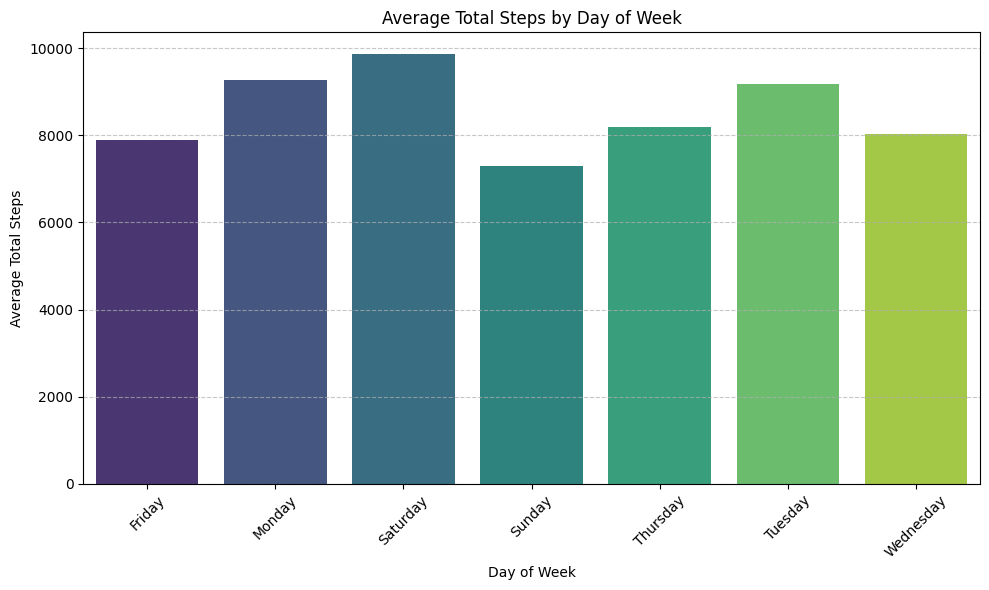

In [21]:
plt.figure(figsize=(10, 6))
seb.barplot(x=merged_df.groupby('DayOfWeek')['TotalSteps'].mean().index, y=merged_df.groupby('DayOfWeek')['TotalSteps'].mean().values, palette='viridis')
plt.title('Average Total Steps by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Total Steps')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1143/2456839232.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seb.barplot(x=merged_df.groupby('DayOfWeek')['Calories'].mean().index, y=merged_df.groupby('DayOfWeek')['Calories'].mean().values, palette='plasma')


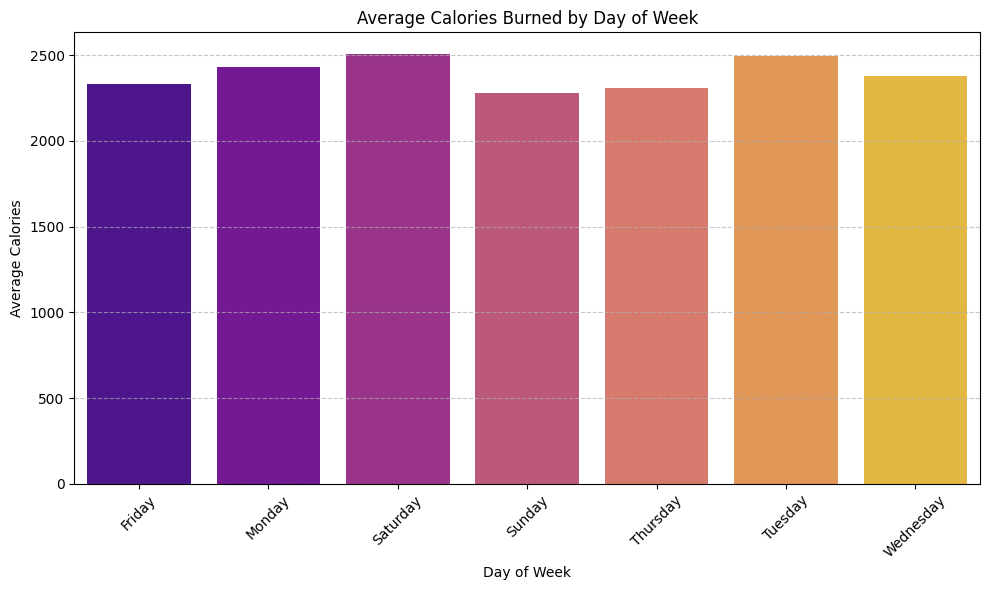

In [22]:
plt.figure(figsize=(10, 6))
seb.barplot(x=merged_df.groupby('DayOfWeek')['Calories'].mean().index, y=merged_df.groupby('DayOfWeek')['Calories'].mean().values, palette='plasma')
plt.title('Average Calories Burned by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Calories')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
merged_df[['TotalSteps', 'Calories']].corr()

,TotalSteps,Calories
TotalSteps,1.000000,0.406301
Calories,0.406301,1.000000


In [24]:
merged_df[['TotalSteps', 'TotalMinutesAsleep']].corr()

,TotalSteps,TotalMinutesAsleep
TotalSteps,1.000000,-0.190344
TotalMinutesAsleep,-0.190344,1.000000
